Escenario 01 CHAPGPT - CON REGLAS, VERSIÓN PAGA



CONTROL DE AVANCE FÍSICO Y VALOR GANADO DE LA OBRA

1. AVANCE FÍSICO CONSOLIDADO
   Avance físico consolidado: 61.14%

2. AVANCE POR DISCIPLINA
   - Civil: 87.39%
   - Eléctrica: 51.46%
   - Instrumentación: 31.42%
   - Mecánica estática: 69.27%
   - Rotativa: 26.21%

3. INDICADORES DE VALOR GANADO - EVM
   PV - Planned Value : USD 39,520,591.76
   EV - Earned Value  : USD 33,947,130.85
   AC - Actual Cost    : USD 35,031,285.00
   SPI                 : 0.8590
   CPI                 : 0.9691

4. INTERPRETACIÓN DE INDICADORES
   SPI: La obra presenta atraso respecto al avance planificado.
   CPI: La obra presenta sobrecosto o desempeño desfavorable de costos.

5. INCONSISTENCIAS DETECTADAS
   1. ID: STAP-ELE-019 | ID de actividad duplicado.
   2. ID: STAP-ELE-019 | ID de actividad duplicado.
   3. ID: STAP-CIV-005 | Cantidad ejecutada mayor que la cantidad planificada.
   4. ID: STAP-CIV-030 | Unidad no reconocida: "m^3".
   5. ID: STAP-MEC-012 | Cantidad ejecutada mayor que la cantid

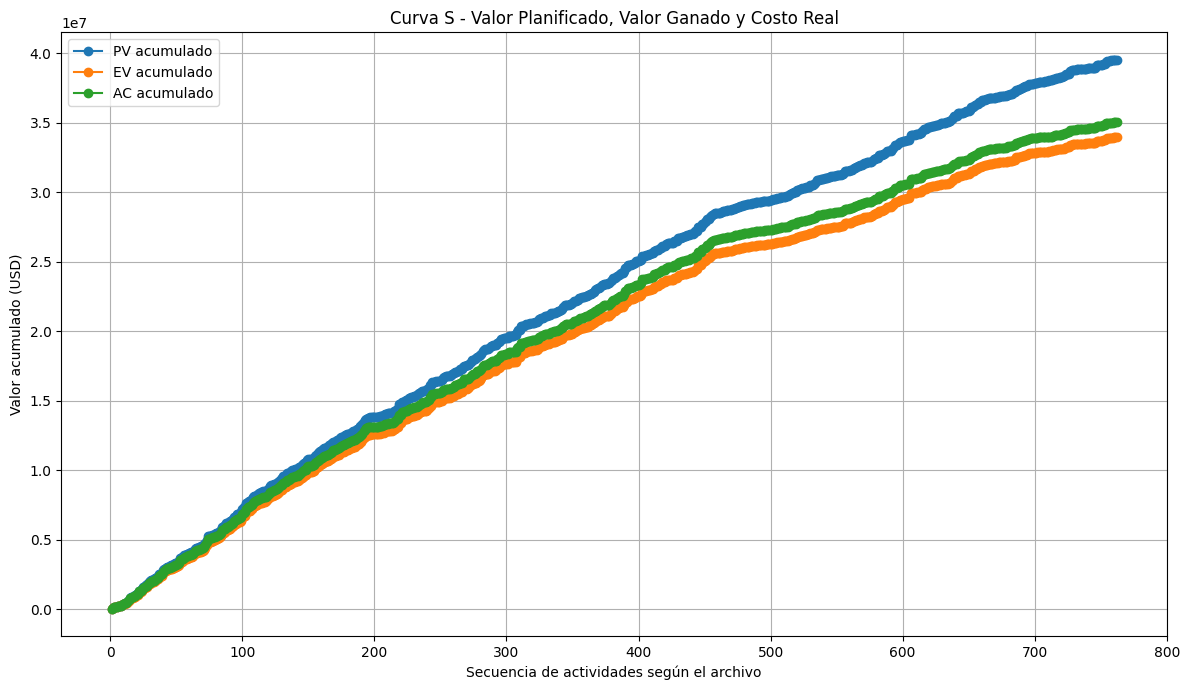

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN
# ============================================================

ARCHIVO = "02_Dataset_Base_STAP.csv"

COLUMNAS_REQUERIDAS = [
    "id_actividad",
    "disciplina",
    "descripcion",
    "unidad",
    "cantidad_planificada",
    "cantidad_ejecutada",
    "peso_presupuesto_usd",
    "avance_planificado_pct",
    "costo_real_usd"
]

UNIDADES_VALIDAS = {
    "pulg_diam",
    "kg",
    "m",
    "m2",
    "m3",
    "und"
}

DISCIPLINAS_VALIDAS = {
    "Civil",
    "Mecánica estática",
    "Rotativa",
    "Instrumentación",
    "Eléctrica"
}


# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def division_segura(numerador, denominador):
    """
    Realiza una división evitando errores por división entre cero.
    Devuelve None cuando el denominador es cero o no es válido.
    """
    if pd.isna(denominador) or denominador == 0:
        return None
    return numerador / denominador


def formato_indicador(valor):
    """
    Formatea indicadores numéricos.
    """
    if valor is None or pd.isna(valor):
        return "No calculable"
    return f"{valor:,.4f}"


def interpretar_spi(spi):
    """
    Interpreta el Schedule Performance Index.
    """
    if spi is None or pd.isna(spi):
        return "SPI no calculable porque el PV es igual a cero."

    if spi > 1:
        return "La obra presenta adelanto respecto al avance planificado."
    elif spi < 1:
        return "La obra presenta atraso respecto al avance planificado."
    else:
        return "La obra se encuentra exactamente de acuerdo con el avance planificado."


def interpretar_cpi(cpi):
    """
    Interpreta el Cost Performance Index.
    """
    if cpi is None or pd.isna(cpi):
        return "CPI no calculable porque el AC es igual a cero."

    if cpi > 1:
        return "La obra presenta ahorro o eficiencia favorable de costos."
    elif cpi < 1:
        return "La obra presenta sobrecosto o desempeño desfavorable de costos."
    else:
        return "La obra se encuentra exactamente de acuerdo con el costo presupuestado para el trabajo ejecutado."


# ============================================================
# LECTURA DEL ARCHIVO
# ============================================================

try:
    df = pd.read_csv(
        ARCHIVO,
        encoding="utf-8",
        sep=","
    )
except FileNotFoundError:
    print("=" * 70)
    print("ERROR")
    print("=" * 70)
    print(
        f'No se encontró el archivo "{ARCHIVO}".\n'
        "Verifique que esté cargado en la misma carpeta de ejecución de Google Colab."
    )
    raise SystemExit

except Exception as error:
    print("=" * 70)
    print("ERROR AL LEER EL ARCHIVO")
    print("=" * 70)
    print(error)
    raise SystemExit


# ============================================================
# VERIFICACIÓN DE COLUMNAS
# ============================================================

columnas_faltantes = [
    columna
    for columna in COLUMNAS_REQUERIDAS
    if columna not in df.columns
]

if columnas_faltantes:
    print("=" * 70)
    print("ERROR: FALTAN COLUMNAS REQUERIDAS")
    print("=" * 70)

    for columna in columnas_faltantes:
        print(f"- {columna}")

    raise SystemExit


# ============================================================
# CONVERSIÓN DE VARIABLES NUMÉRICAS
# ============================================================

columnas_numericas = [
    "cantidad_planificada",
    "cantidad_ejecutada",
    "peso_presupuesto_usd",
    "avance_planificado_pct",
    "costo_real_usd"
]

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    )


# ============================================================
# VALIDACIONES
# ============================================================

inconsistencias = []


def registrar_inconsistencia(id_actividad, mensaje):
    """
    Agrega una inconsistencia a la lista general.
    """
    inconsistencias.append({
        "id_actividad": id_actividad,
        "inconsistencia": mensaje
    })


# ------------------------------------------------------------
# 1. ID de actividad duplicado
# ------------------------------------------------------------

duplicados = df["id_actividad"].duplicated(keep=False)

for _, fila in df[duplicados].iterrows():
    registrar_inconsistencia(
        fila["id_actividad"],
        "ID de actividad duplicado."
    )


# ------------------------------------------------------------
# 2. Validaciones fila por fila
# ------------------------------------------------------------

for _, fila in df.iterrows():

    id_actividad = fila["id_actividad"]

    # Cantidad ejecutada mayor que cantidad planificada
    if (
        pd.notna(fila["cantidad_ejecutada"])
        and pd.notna(fila["cantidad_planificada"])
        and fila["cantidad_ejecutada"] > fila["cantidad_planificada"]
    ):
        registrar_inconsistencia(
            id_actividad,
            "Cantidad ejecutada mayor que la cantidad planificada."
        )

    # Peso presupuestal ausente
    if pd.isna(fila["peso_presupuesto_usd"]):
        registrar_inconsistencia(
            id_actividad,
            "Peso presupuestal ausente."
        )

    # Peso presupuestal nulo
    elif fila["peso_presupuesto_usd"] == 0:
        registrar_inconsistencia(
            id_actividad,
            "Peso presupuestal nulo."
        )

    # Peso presupuestal negativo
    elif fila["peso_presupuesto_usd"] < 0:
        registrar_inconsistencia(
            id_actividad,
            "Peso presupuestal negativo."
        )

    # Unidad no reconocida
    if (
        pd.isna(fila["unidad"])
        or fila["unidad"] not in UNIDADES_VALIDAS
    ):
        registrar_inconsistencia(
            id_actividad,
            f'Unidad no reconocida: "{fila["unidad"]}".'
        )

    # Disciplina no reconocida
    if (
        pd.isna(fila["disciplina"])
        or fila["disciplina"] not in DISCIPLINAS_VALIDAS
    ):
        registrar_inconsistencia(
            id_actividad,
            f'Disciplina no reconocida: "{fila["disciplina"]}".'
        )

    # Avance planificado fuera de [0, 1]
    if pd.notna(fila["avance_planificado_pct"]):
        if (
            fila["avance_planificado_pct"] < 0
            or fila["avance_planificado_pct"] > 1
        ):
            registrar_inconsistencia(
                id_actividad,
                "Avance planificado fuera del rango [0, 1]."
            )


# ============================================================
# CÁLCULO DEL AVANCE DE CADA ACTIVIDAD
# ============================================================

def calcular_avance_actividad(fila):
    """
    Avance = cantidad_ejecutada / cantidad_planificada,
    acotado al intervalo [0, 1].

    Para cantidades planificadas nulas o iguales a cero,
    se asigna avance cero para evitar división por cero.
    """

    cantidad_planificada = fila["cantidad_planificada"]
    cantidad_ejecutada = fila["cantidad_ejecutada"]

    if (
        pd.isna(cantidad_planificada)
        or cantidad_planificada == 0
        or pd.isna(cantidad_ejecutada)
    ):
        return 0.0

    avance = cantidad_ejecutada / cantidad_planificada

    # Acotar a [0, 1]
    return max(0.0, min(1.0, avance))


df["avance_actividad"] = df.apply(
    calcular_avance_actividad,
    axis=1
)


# ============================================================
# AVANCE FÍSICO CONSOLIDADO
# ============================================================

# Para los cálculos, los pesos ausentes se consideran cero.
# Los valores originales permanecen disponibles para las validaciones.

df["peso_calculo"] = df["peso_presupuesto_usd"].fillna(0)

suma_pesos = df["peso_calculo"].sum()

if suma_pesos != 0:
    avance_fisico_consolidado = (
        (
            df["avance_actividad"]
            * df["peso_calculo"]
        ).sum()
        / suma_pesos
    )
else:
    avance_fisico_consolidado = None


# ============================================================
# AVANCE POR DISCIPLINA
# ============================================================

avance_por_disciplina = {}

for disciplina, grupo in df.groupby(
    "disciplina",
    dropna=False
):

    suma_pesos_disciplina = grupo["peso_calculo"].sum()

    if suma_pesos_disciplina != 0:

        avance = (
            (
                grupo["avance_actividad"]
                * grupo["peso_calculo"]
            ).sum()
            / suma_pesos_disciplina
        )

        avance_por_disciplina[disciplina] = avance

    else:
        avance_por_disciplina[disciplina] = None


# ============================================================
# EARNED VALUE MANAGEMENT - EVM
# ============================================================

# Valores ausentes se sustituyen por cero únicamente
# para permitir que el cálculo general continúe.

avance_planificado_calculo = (
    df["avance_planificado_pct"]
    .fillna(0)
)

costo_real_calculo = (
    df["costo_real_usd"]
    .fillna(0)
)

# Planned Value
PV = (
    df["peso_calculo"]
    * avance_planificado_calculo
).sum()

# Earned Value
EV = (
    df["peso_calculo"]
    * df["avance_actividad"]
).sum()

# Actual Cost
AC = costo_real_calculo.sum()

# Indicadores
SPI = division_segura(EV, PV)
CPI = division_segura(EV, AC)


# ============================================================
# SALIDA DE RESULTADOS
# ============================================================

print("\n")
print("=" * 70)
print("CONTROL DE AVANCE FÍSICO Y VALOR GANADO DE LA OBRA")
print("=" * 70)


# ------------------------------------------------------------
# Avance físico consolidado
# ------------------------------------------------------------

print("\n1. AVANCE FÍSICO CONSOLIDADO")

if avance_fisico_consolidado is not None:
    print(
        f"   Avance físico consolidado: "
        f"{avance_fisico_consolidado * 100:,.2f}%"
    )
else:
    print(
        "   Avance físico consolidado: No calculable "
        "porque la suma de los pesos presupuestales es cero."
    )


# ------------------------------------------------------------
# Avance por disciplina
# ------------------------------------------------------------

print("\n2. AVANCE POR DISCIPLINA")

for disciplina, avance in avance_por_disciplina.items():

    if avance is not None:
        print(
            f"   - {disciplina}: "
            f"{avance * 100:,.2f}%"
        )
    else:
        print(
            f"   - {disciplina}: "
            "No calculable por suma de pesos igual a cero."
        )


# ------------------------------------------------------------
# Indicadores EVM
# ------------------------------------------------------------

print("\n3. INDICADORES DE VALOR GANADO - EVM")

print(f"   PV - Planned Value : USD {PV:,.2f}")
print(f"   EV - Earned Value  : USD {EV:,.2f}")
print(f"   AC - Actual Cost    : USD {AC:,.2f}")

print(f"   SPI                 : {formato_indicador(SPI)}")
print(f"   CPI                 : {formato_indicador(CPI)}")


# ------------------------------------------------------------
# Interpretación
# ------------------------------------------------------------

print("\n4. INTERPRETACIÓN DE INDICADORES")

print(f"   SPI: {interpretar_spi(SPI)}")
print(f"   CPI: {interpretar_cpi(CPI)}")


# ------------------------------------------------------------
# Inconsistencias
# ------------------------------------------------------------

print("\n5. INCONSISTENCIAS DETECTADAS")

if len(inconsistencias) == 0:

    print("   No se detectaron inconsistencias.")

else:

    for numero, inconsistencia in enumerate(
        inconsistencias,
        start=1
    ):

        print(
            f"   {numero}. "
            f"ID: {inconsistencia['id_actividad']} | "
            f"{inconsistencia['inconsistencia']}"
        )

    print(
        f"\n   Total de inconsistencias detectadas: "
        f"{len(inconsistencias)}"
    )


# ============================================================
# CURVA S ACUMULADA
# ============================================================

# Debido a que el archivo especificado no contiene una columna
# de fecha o periodo, la curva S se construye siguiendo el orden
# de las actividades en el archivo.

df["PV_actividad"] = (
    df["peso_calculo"]
    * avance_planificado_calculo
)

df["EV_actividad"] = (
    df["peso_calculo"]
    * df["avance_actividad"]
)

df["AC_actividad"] = costo_real_calculo


# Acumulados
df["PV_acumulado"] = df["PV_actividad"].cumsum()
df["EV_acumulado"] = df["EV_actividad"].cumsum()
df["AC_acumulado"] = df["AC_actividad"].cumsum()


# Eje X
eje_x = range(
    1,
    len(df) + 1
)


# Gráfica
plt.figure(figsize=(12, 7))

plt.plot(
    eje_x,
    df["PV_acumulado"],
    marker="o",
    label="PV acumulado"
)

plt.plot(
    eje_x,
    df["EV_acumulado"],
    marker="o",
    label="EV acumulado"
)

plt.plot(
    eje_x,
    df["AC_acumulado"],
    marker="o",
    label="AC acumulado"
)

plt.title(
    "Curva S - Valor Planificado, Valor Ganado y Costo Real"
)

plt.xlabel(
    "Secuencia de actividades según el archivo"
)

plt.ylabel(
    "Valor acumulado (USD)"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()